In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torch
import torchvision.models as models
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from tqdm import tqdm
from util import *

import copy
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
num_workers = 12
imagenet_data_path = '/home/dw217/ImageNet/imagenet'
model_name = "MobileNet"

In [2]:
train_loader, test_loader = get_imagenet_loaders(imagenet_data_path, batch_size, num_workers)

In [3]:
model = get_model(model_name).to(device)
model
# Print model architecture
print(model)

MobileNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
  (bn

In [4]:
unpruned_accuracy = test(model, test_loader, device)
print(f"Unpruned model accuracy: {unpruned_accuracy:.2f}%")

100%|██████████| 196/196 [00:33<00:00,  5.88it/s]

Unpruned model accuracy: 71.96%


In [5]:
pruned_model = global_pruning(copy.deepcopy(model), 0.7)

pruned_accuracy = test(pruned_model, test_loader, device)
print(f"Pruned model accuracy: {pruned_accuracy:.2f}%")

100%|██████████| 196/196 [00:33<00:00,  5.89it/s]

Pruned model accuracy: 6.78%


In [6]:
pruned_model_updated_bn = (copy.deepcopy(pruned_model))
model_update_bn(pruned_model_updated_bn, train_loader, device, count = 100)

pruned_accuracy_updated_bn = test(pruned_model_updated_bn, test_loader, device)
print(f"Pruned model with updated BN accuracy: {pruned_accuracy_updated_bn:.2f}%")

100%|██████████| 196/196 [00:33<00:00,  5.89it/s]

Pruned model with updated BN accuracy: 61.52%


In [7]:
from stats import *

In [8]:
batches = sample_batches(train_loader, device, num_batches=100)

orig_stats  = collect_bn_activation_stats_from_batches(model,                 batches, device)
pruned_stats= collect_bn_activation_stats_from_batches(pruned_model,          batches, device)
recal_stats = collect_bn_activation_stats_from_batches(pruned_model_updated_bn,batches, device)

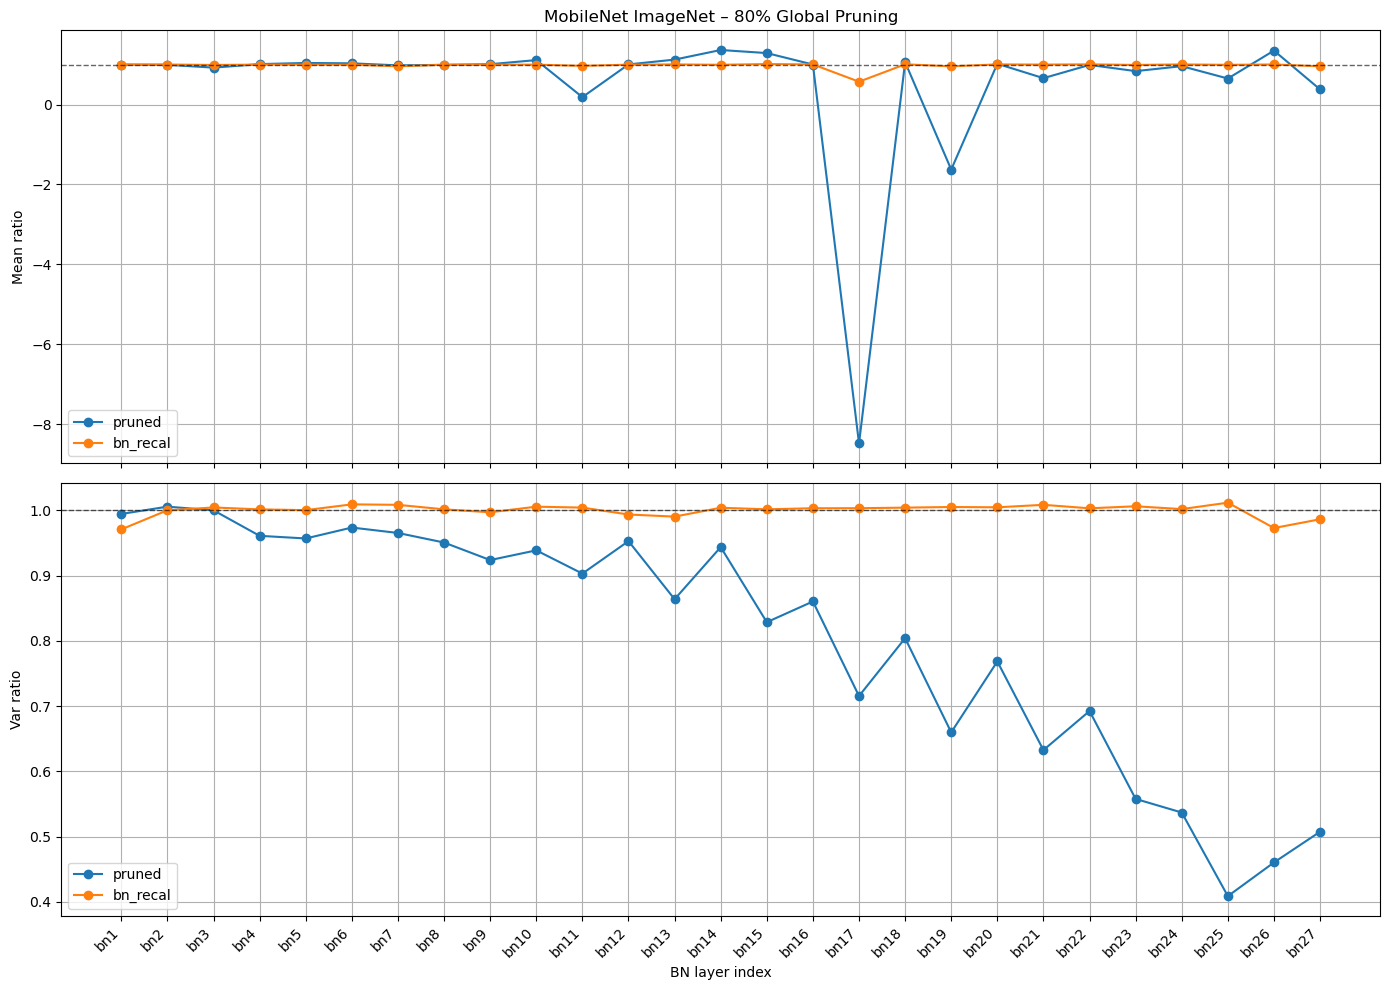

In [10]:
ratio_res = compare_stats_ratio(orig_stats,
                                {'pruned': pruned_stats,
                                 'bn_recal': recal_stats})

# 3. plot
plot_stat_ratios(ratio_res, title="MobileNet ImageNet – 80% Global Pruning")